In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.scale import LogisticTransform
from sklearn import pipeline

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, accuracy_score, precision_score

In [5]:
model = PolynomialFeatures(degree=3, include_bias=False)

model.fit_transform([[2, 3], [4, 5]])

array([[  2.,   3.,   4.,   6.,   9.,   8.,  12.,  18.,  27.],
       [  4.,   5.,  16.,  20.,  25.,  64.,  80., 100., 125.]])

In [6]:
np.random.seed(42)
x = np.linspace(-3, 3, 200)
y = 1.5 * x - 0.8 * x ** 2 + 2 + np.random.normal(0, 1.2, size=200)
X = x.reshape(-1, 1)

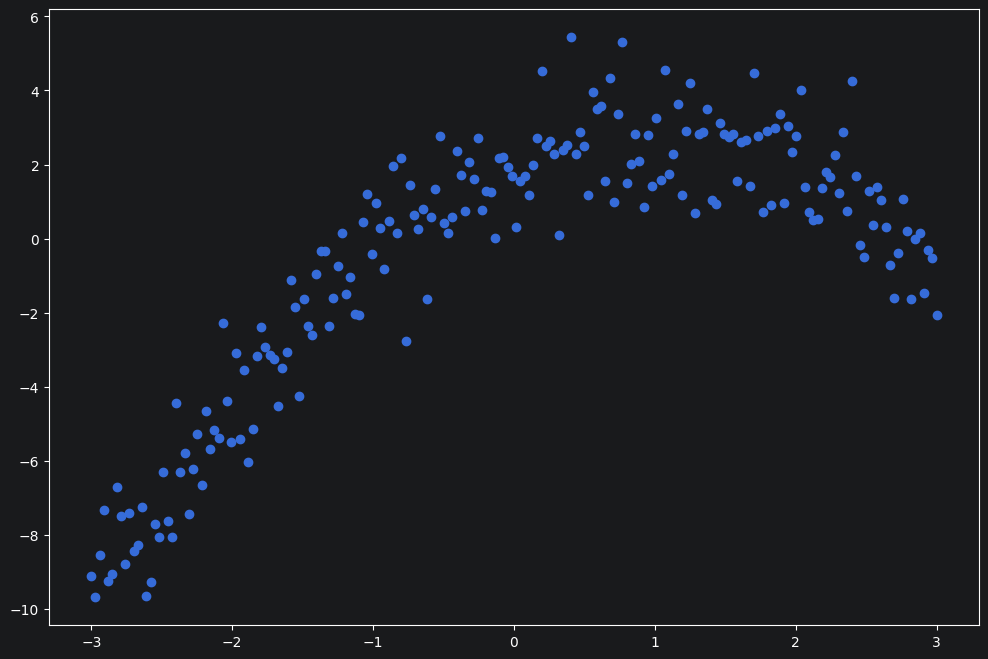

In [7]:
plt.figure(figsize=(12, 8))

plt.scatter(x, y)

plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

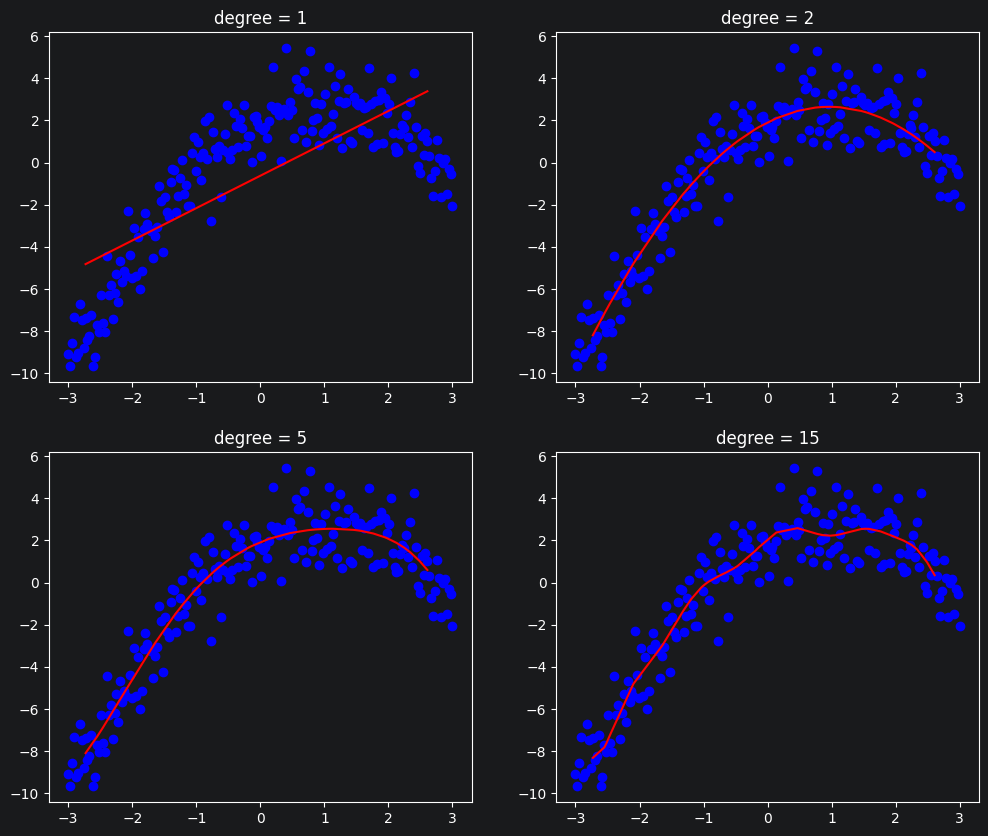

In [9]:
metrics = []

plt.figure(figsize=(12, 10))

result = []

n = 0
for d in [1, 2, 5, 15]:
    n += 1
    plt.subplot(2, 2, n)

    model = Pipeline(steps=[
        ("poly", PolynomialFeatures(d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])

    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    plt.scatter(x, y, color='blue')
    indx_sort = np.argsort(X_test[:, 0])
    plt.plot(X_test[indx_sort], y_pred_test[indx_sort], color='red')

    result.append({
        "index": indx_sort,
        "X_test": X_test[indx_sort],
        "y_pred_test": y_pred_test[indx_sort]
    })

    plt.title("degree = " + str(d))

    metrics.append({
        "degree": d,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test)
    })

plt.show()

In [16]:
pd.DataFrame(result)

,index,X_test,y_pred_test
0,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-4.8209445220876725, -4.542637443375454, -4.4..."
1,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-8.198908473865838, -7.161806058452766, -6.99..."
2,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-8.097761582773366, -7.308432228120482, -7.16..."
3,"[30, 1, 21, 31, 2, 9, 32, 16, 25, 24, 10, 27, ...","[[-2.728643216080402], [-2.5477386934673367], ...","[-8.323047925018045, -7.8196540763248095, -7.6..."


In [17]:
pd.DataFrame(metrics)

,degree,r2_train,r2_test
0,1,0.548510,0.492246
1,2,0.907735,0.897404
2,5,0.911491,0.900050
3,15,0.914993,0.894905


In [18]:

X, y = make_regression(n_samples=500, n_features=20, n_informative=5, noise=10, random_state=42)

In [19]:
print(X.shape, y.shape)

(500, 20) (500,)


In [20]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
models = {
    "LinearRegression": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Lasso": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=1.0, max_iter=1000))
    ]),
    "Ridge": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=0.1))
    ])
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    coef = model.named_steps['model'].coef_
    print(coef)
    non_zero = np.sum(np.abs(coef) > 0.0000001)
    rows.append({
        "model": name,
        "r2": r2_score(y_test, y_pred),
        "non_zero": non_zero
    })

[-4.75955982e-02  4.46077211e-01  7.50995674e+00 -5.39804192e-01
 -4.18941644e-01  3.47925118e-01  6.07639349e+01  3.12934456e+01
  2.31913539e-01  1.02167905e+01 -8.29251365e-01  1.82408073e-02
  7.58527053e-01  9.02002417e+00 -6.72314083e-02 -7.11478775e-03
  9.80874687e-02  2.33412456e-02  6.87074245e-01 -9.47227371e-02]
[-0.          0.          6.39754235 -0.         -0.          0.
 59.74388512 30.29295734  0.          9.39506182 -0.          0.
  0.          8.040803   -0.         -0.          0.         -0.
  0.         -0.        ]
[-4.74157617e-02  4.45274696e-01  7.50865744e+00 -5.39705848e-01
 -4.19281570e-01  3.47982248e-01  6.07484168e+01  3.12852924e+01
  2.31791700e-01  1.02143830e+01 -8.28479642e-01  1.97816098e-02
  7.57654183e-01  9.01772484e+00 -6.71586238e-02 -7.77769806e-03
  9.76241248e-02  2.32329689e-02  6.87185418e-01 -9.63884458e-02]


In [22]:
pd.DataFrame(rows)

,model,r2,non_zero
0,LinearRegression,0.978411,20
1,Lasso,0.979109,5
2,Ridge,0.978419,20


In [23]:
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor

housing_df = fetch_california_housing(as_frame=True).frame

X = housing_df.drop(columns=["MedHouseVal"])
y = housing_df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(r2_train, r2_test)

0.8347775350789697 0.6821690371438849


In [ ]:
from sklearn.datasets import load_breast_cancera

df = load_breast_cancera(as_frame=True).frame
df.head()

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=True)

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("regressor", LogisticTransform(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipline.predict(X_test)

metrics = pd.DataFrame({
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    ''
})